# COS720 – AI-Powered Insider Threat Detection System
## Notebook 04: AI Explainability

**Objective:** Demonstrate explainability of the Random Forest model through feature importance analysis, risk score breakdown, and human-readable explanations — meeting the project specification requirement that explanations must be understandable to a non-technical manager.

---
### Explainability Techniques Used
1. **Global Feature Importance** — which features matter most across the entire model
2. **Per-prediction risk score breakdown** — what drove each individual decision
3. **Behavioural anomaly flagging** — which specific values are unusual
4. **Human-readable risk narrative** — plain-language output for managers
5. **Testing scenarios** — true positives, false positives, false negatives documented

## 1. Setup

In [3]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pickle, warnings

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 120})

models_dir = '/Users/wadalisam/Documents/GitHub/insider-threat-detector/models/'
figures_dir = '/Users/wadalisam/Documents/GitHub/insider-threat-detector/figures/'
os.makedirs(figures_dir, exist_ok=True)

with open (f'{models_dir}recall_model.pkl', 'rb') as  f: model = pickle.load(f)
with open (f'{models_dir}encoders.pkl', 'rb') as f: encoders = pickle.load(f)
with open (f'{models_dir}feature_names.pkl', 'rb') as f: feature_names = pickle.load(f)
with open (f'{models_dir}splits.pkl', 'rb') as f: splits = pickle.load(f)


X_test = splits['X_test']
y_test = splits['y_test']

# Reconstitute a DataFrame with named columns
X_test_df = pd.DataFrame(X_test, columns=feature_names)
y_pred    = model.predict(X_test)
y_prob    = model.predict_proba(X_test)[:, 1]

print('Artifacts loaded. Test set:', X_test_df.shape)

Artifacts loaded. Test set: (23723, 20)


## 2. Global Feature Importance

In [8]:
def get_feature_importances(model, feature_names):
    """Extract feature importances from any model or VotingClassifier."""
    if hasattr(model, 'feature_importances_'):
        return pd.Series(model.feature_importances_, index=feature_names)
    
    elif hasattr(model, 'estimators_'):
        # VotingClassifier: .estimators_ is a list of fitted objects (no names)
        # Use .estimators (unfitted, with names) to pair them up
        importances = []
        for estimator in model.estimators_:
            # Unwrap Pipeline (e.g. lr_pipe)
            inner = estimator.named_steps['lr'] if hasattr(estimator, 'named_steps') else estimator
            if hasattr(inner, 'feature_importances_'):
                importances.append(inner.feature_importances_)
        
        if importances:
            avg = np.mean(importances, axis=0)
            return pd.Series(avg, index=feature_names)
        else:
            print(f'No tree-based estimators found in VotingClassifier — cannot compute feature importances.')
            return None
    else:
        print(f'{type(model).__name__} does not support feature importances.')
        return None


fi = get_feature_importances(model, feature_names)

if fi is not None:
    fi = fi.sort_values(ascending=False)
    print('Feature Importances (Gini Impurity Reduction):')
    for feat, score in fi.items():
        bar = '█' * int(score * 200)
        print(f'  {feat:<35} {score:.4f}  {bar}')

Feature Importances (Gini Impurity Reduction):
  total_files_burned                  0.2692  █████████████████████████████████████████████████████
  total_printed_pages                 0.1678  █████████████████████████████████
  employee_position                   0.0958  ███████████████████
  employee_seniority_years            0.0957  ███████████████████
  employee_origin_country             0.0829  ████████████████
  employee_department                 0.0599  ███████████
  num_printed_pages_off_hours         0.0464  █████████
  employee_classification             0.0330  ██████
  employee_campus                     0.0321  ██████
  num_unique_campus                   0.0270  █████
  num_entries                         0.0175  ███
  has_foreign_citizenship             0.0133  ██
  is_contractor                       0.0131  ██
  has_medical_history                 0.0116  ██
  trip_day_number                     0.0088  █
  hostility_country_level             0.0082  █
  has_crimina

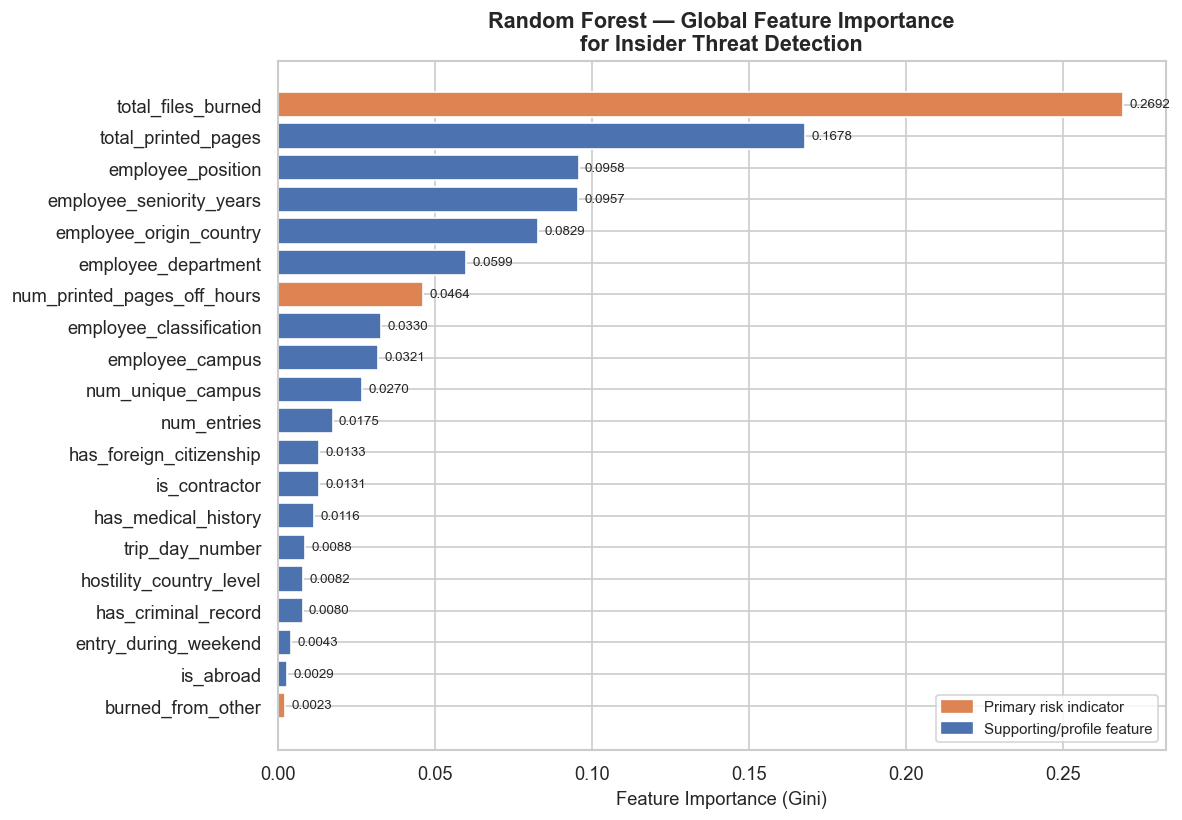


Top 5 most important features:
  1. total_files_burned: 0.2692 (26.9% of total importance)
  2. total_printed_pages: 0.1678 (16.8% of total importance)
  3. employee_position: 0.0958 (9.6% of total importance)
  4. employee_seniority_years: 0.0957 (9.6% of total importance)
  5. employee_origin_country: 0.0829 (8.3% of total importance)


In [9]:
# Visual feature importance
fi_sorted = fi.sort_values(ascending=True)
high_risk = {'total_files_burned', 'burned_from_other', 'num_printed_pages_off_hours'}
colors_fi = ['#DD8452' if f in high_risk else '#4C72B0' for f in fi_sorted.index]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(fi_sorted.index, fi_sorted.values, color=colors_fi, edgecolor='white')
ax.set_xlabel('Feature Importance (Gini)', fontsize=11)
ax.set_title('Random Forest — Global Feature Importance\nfor Insider Threat Detection', fontsize=13, fontweight='bold')

for bar, val in zip(bars, fi_sorted.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)

red_p  = mpatches.Patch(color='#DD8452', label='Primary risk indicator')
blue_p = mpatches.Patch(color='#4C72B0', label='Supporting/profile feature')
ax.legend(handles=[red_p, blue_p], loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

print('\nTop 5 most important features:')
for i, (feat, score) in enumerate(fi.head(5).items(), 1):
    print(f'  {i}. {feat}: {score:.4f} ({score*100:.1f}% of total importance)')

## 3. Per-Prediction Risk Score Breakdown

For each prediction, the model's confidence is decomposed by examining which feature values deviate most from the normal population. This gives security analysts a concrete, ranked list of why a specific employee was flagged.

In [11]:
def get_risk_breakdown(row: pd.Series, feature_names: list, model) -> pd.Series:
    """
    Approximates per-feature contribution to the malicious class prediction
    by weighting the feature's importance by how extreme its value is
    relative to the training population median.
    """
    importances = pd.Series(fi, index=feature_names)
    
    # Normalise each value against the feature's range seen in test set
    contributions = {}
    for feat in feature_names:
        val = row[feat]
        feat_range = X_test_df[feat].max() - X_test_df[feat].min()
        normalised = val / feat_range if feat_range > 0 else 0
        contributions[feat] = normalised * importances[feat]
    
    contrib_series = pd.Series(contributions)
    total = contrib_series.sum()
    return (contrib_series / total * 100).sort_values(ascending=False) if total > 0 else contrib_series


def explain_prediction(idx: int):
    """Full explanation for a single prediction."""
    row   = X_test_df.iloc[idx]
    pred  = y_pred[idx]
    prob  = y_prob[idx]
    truth = y_test.iloc[idx]
    
    outcome = ('✅ True Positive'  if pred==1 and truth==1 else
               '✅ True Negative'  if pred==0 and truth==0 else
               '⚠️ False Positive' if pred==1 and truth==0 else
               '❌ False Negative')

    print(f'━━━ Record #{idx} ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
    print(f'Ground truth:  {"MALICIOUS" if truth==1 else "NORMAL"}')
    print(f'Prediction:    {"MALICIOUS" if pred==1  else "NORMAL"}')
    print(f'Confidence:    {prob*100:.1f}% malicious')
    print(f'Outcome:       {outcome}')
    
    breakdown = get_risk_breakdown(row, feature_names, model)
    print('\nTop contributing features:')
    for feat, pct in breakdown.head(6).items():
        val = row[feat]
        print(f'  {feat:<35} value={val:.1f}  contribution≈{pct:.1f}%')

    print()


# Show one true positive, one true negative, one FP, one FN
tp_idx = next(i for i in range(len(y_pred)) if y_pred[i]==1 and y_test.iloc[i]==1 and y_prob[i]>0.8)
tn_idx = next(i for i in range(len(y_pred)) if y_pred[i]==0 and y_test.iloc[i]==0 and y_prob[i]<0.1)

fp_candidates = [i for i in range(len(y_pred)) if y_pred[i]==1 and y_test.iloc[i]==0]
fn_candidates = [i for i in range(len(y_pred)) if y_pred[i]==0 and y_test.iloc[i]==1]

print(f'Found {len(fp_candidates):,} false positives and {len(fn_candidates):,} false negatives in test set.\n')

for idx in [tp_idx, tn_idx, fp_candidates[0], fn_candidates[0]]:
    explain_prediction(idx)

Found 571 false positives and 257 false negatives in test set.

━━━ Record #32 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Ground truth:  MALICIOUS
Prediction:    MALICIOUS
Confidence:    98.6% malicious
Outcome:       ✅ True Positive

Top contributing features:
  total_files_burned                  value=69.0  contribution≈31.7%
  employee_seniority_years            value=22.0  contribution≈20.5%
  employee_position                   value=22.0  contribution≈13.6%
  employee_classification             value=3.0  contribution≈10.0%
  employee_origin_country             value=12.0  contribution≈9.7%
  employee_campus                     value=2.0  contribution≈9.7%

━━━ Record #0 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Ground truth:  NORMAL
Prediction:    NORMAL
Confidence:    8.6% malicious
Outcome:       ✅ True Negative

Top contributing features:
  employee_origin_country             value=22.0  contribution≈27.4%
  employee_department                 value=9.0  contribution≈25.1%
  em

## 4. Visual Per-Record Explanation

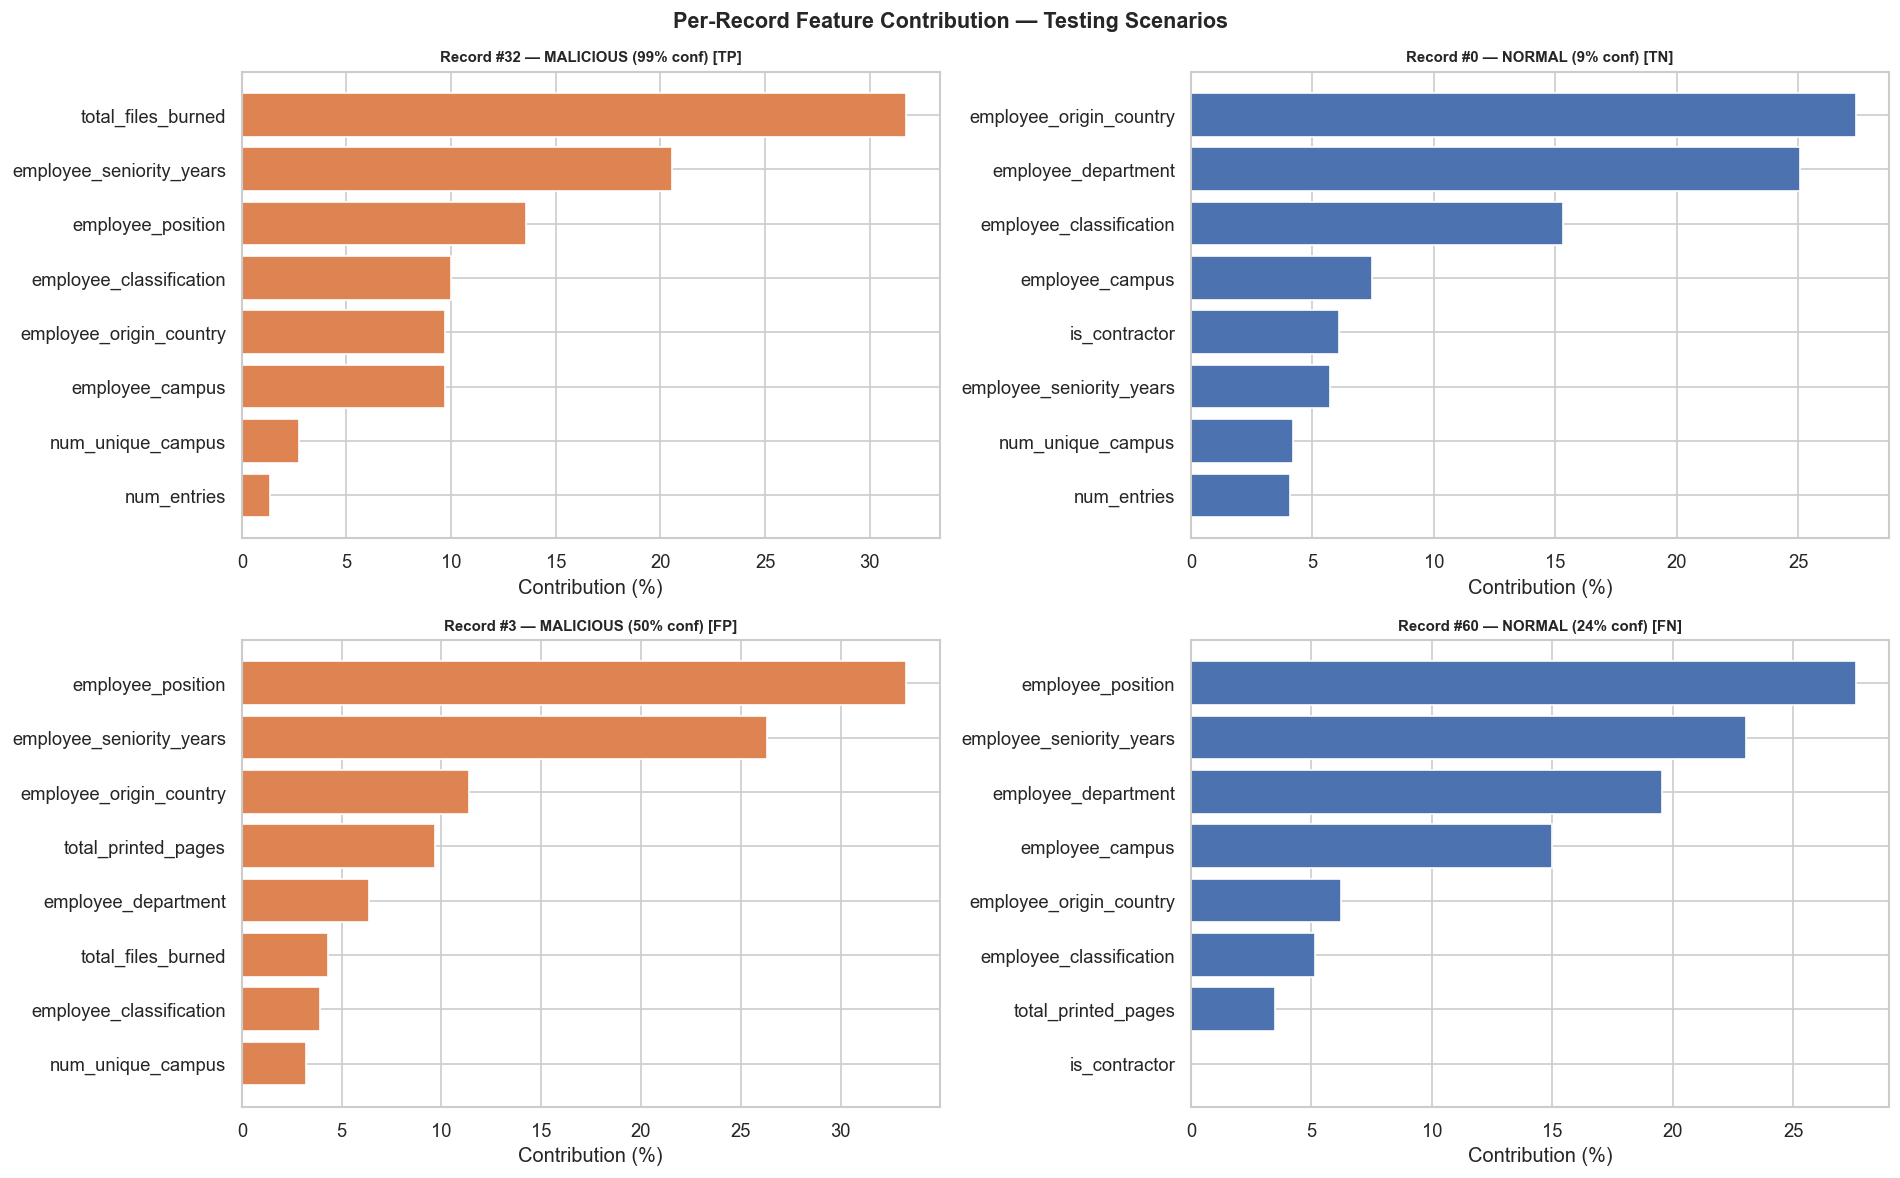

In [12]:
def plot_risk_breakdown(idx: int, ax):
    row      = X_test_df.iloc[idx]
    pred     = y_pred[idx]
    prob     = y_prob[idx]
    truth    = y_test.iloc[idx]
    breakdown = get_risk_breakdown(row, feature_names, model).head(8)

    colors = ['#DD8452' if pred == 1 else '#4C72B0'] * len(breakdown)
    ax.barh(breakdown.index, breakdown.values, color=colors, edgecolor='white')
    ax.set_xlabel('Contribution (%)')
    outcome = ('TP' if pred==1 and truth==1 else 'TN' if pred==0 and truth==0
               else 'FP' if pred==1 else 'FN')
    ax.set_title(
        f'Record #{idx} — {"MALICIOUS" if pred==1 else "NORMAL"} ({prob*100:.0f}% conf) [{outcome}]',
        fontweight='bold', fontsize=9
    )

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
scenarios = [
    (tp_idx,              'True Positive'),
    (tn_idx,              'True Negative'),
    (fp_candidates[0],    'False Positive'),
    (fn_candidates[0],    'False Negative'),
]
for ax, (idx, label) in zip(axes.flatten(), scenarios):
    plot_risk_breakdown(idx, ax)
    ax.invert_yaxis()

plt.suptitle('Per-Record Feature Contribution — Testing Scenarios', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Human-Readable Risk Narrative Generator

This function produces a plain-language summary suitable for non-technical security managers.

In [13]:
def generate_narrative(idx: int) -> str:
    row   = X_test_df.iloc[idx]
    pred  = y_pred[idx]
    prob  = y_prob[idx]
    truth = y_test.iloc[idx]

    risk_label = ('CRITICAL' if prob > 0.80 else 'HIGH' if prob > 0.60
                  else 'MEDIUM' if prob > 0.30 else 'LOW')

    lines = []
    lines.append(f'=== INSIDER THREAT ASSESSMENT REPORT ===')
    lines.append(f'Record ID:       #{idx}')
    lines.append(f'Verdict:         {"⚠  MALICIOUS" if pred == 1 else "✔  NORMAL"}')
    lines.append(f'Risk Level:      {risk_label}')
    lines.append(f'Confidence:      {prob*100:.1f}% probability of malicious intent')
    lines.append(f'')
    lines.append('RISK INDICATORS DETECTED:')

    flags = []
    if row['total_files_burned'] > 5:
        flags.append(f'• HIGH: Employee copied {row["total_files_burned"]:.0f} files to removable media — '
                     f'far above the organisational average. This is the strongest indicator of data exfiltration.')
    elif row['total_files_burned'] > 0:
        flags.append(f'• MEDIUM: {row["total_files_burned"]:.0f} file(s) were copied to removable media.')

    if row['num_printed_pages_off_hours'] > 0:
        flags.append(f'• HIGH: {row["num_printed_pages_off_hours"]:.0f} pages were printed outside normal '
                     f'business hours. Off-hours printing is a recognised data exfiltration technique.')

    if row['burned_from_other'] > 0:
        flags.append(f'• HIGH: Employee accessed and copied {row["burned_from_other"]:.0f} file(s) '
                     f'belonging to other employees. This indicates possible unauthorised access.')

    if row['entry_during_weekend'] == 1:
        flags.append('• MEDIUM: Employee accessed the building during the weekend when not typically required.')

    if row['num_unique_campus'] > 1:
        flags.append(f'• MEDIUM: Employee visited {row["num_unique_campus"]:.0f} different campuses, '
                     f'which is unusual for their role.')

    if row['hostility_country_level'] > 0:
        flags.append(f'• MEDIUM: Employee is associated with a country at threat hostility '
                     f'level {row["hostility_country_level"]:.0f}/4.')

    if row['is_abroad'] == 1:
        flags.append('• MEDIUM: Activity occurred while employee was abroad.')

    if not flags:
        flags.append('• No single high-risk indicator was identified. The classification '
                     'is based on the combined pattern of multiple low-level behavioural signals.')

    lines.extend(flags)
    lines.append('')
    lines.append('RECOMMENDED ACTION:')
    if pred == 1 and prob > 0.80:
        lines.append('⚠  CRITICAL: Escalate to the Security Operations Centre immediately.'
                     ' Suspend all system access. Preserve logs for forensic investigation.')
    elif pred == 1:
        lines.append('⚠  HIGH: Flag for urgent security team review. Increase monitoring '
                     'frequency and cross-reference physical access records.')
    elif prob > 0.30:
        lines.append('○  MEDIUM: Schedule a routine review. Continue passive monitoring.')
    else:
        lines.append('✔  LOW: No action required. Behaviour is within normal parameters.')

    return '\n'.join(lines)


# Demonstrate for the true positive case
print(generate_narrative(tp_idx))
print()
print(generate_narrative(fp_candidates[0]))

=== INSIDER THREAT ASSESSMENT REPORT ===
Record ID:       #32
Verdict:         ⚠  MALICIOUS
Risk Level:      CRITICAL
Confidence:      98.6% probability of malicious intent

RISK INDICATORS DETECTED:
• HIGH: Employee copied 69 files to removable media — far above the organisational average. This is the strongest indicator of data exfiltration.
• HIGH: Employee accessed and copied 1 file(s) belonging to other employees. This indicates possible unauthorised access.

RECOMMENDED ACTION:
⚠  CRITICAL: Escalate to the Security Operations Centre immediately. Suspend all system access. Preserve logs for forensic investigation.

=== INSIDER THREAT ASSESSMENT REPORT ===
Record ID:       #3
Verdict:         ⚠  MALICIOUS
Risk Level:      MEDIUM
Confidence:      50.3% probability of malicious intent

RISK INDICATORS DETECTED:
• HIGH: Employee copied 8 files to removable media — far above the organisational average. This is the strongest indicator of data exfiltration.

RECOMMENDED ACTION:
⚠  HIGH: 

## 6. Testing Scenarios — TP / FP / FN Analysis

=== Test Set Results ===
True  Positives (TP) — correctly flagged malicious:         1,020
True  Negatives (TN) — correctly cleared normal:            21,875
False Positives (FP) — normal employees wrongly flagged:    571
False Negatives (FN) — malicious employees missed:          257

Precision: 64.11% — of all flagged, this many were actually malicious
Recall:    79.87% — of all real threats, this many were detected
F1-Score:  71.13%


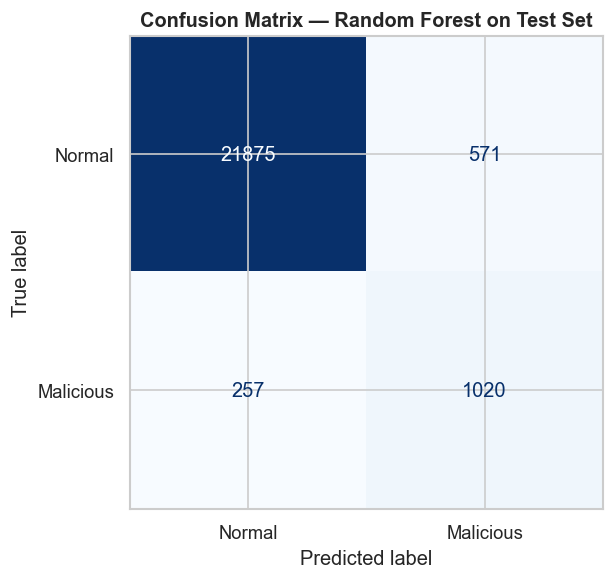

In [14]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print('=== Test Set Results ===')
print(f'True  Positives (TP) — correctly flagged malicious:         {tp:,}')
print(f'True  Negatives (TN) — correctly cleared normal:            {tn:,}')
print(f'False Positives (FP) — normal employees wrongly flagged:    {fp:,}')
print(f'False Negatives (FN) — malicious employees missed:          {fn:,}')
print()
print(f'Precision: {tp/(tp+fp)*100:.2f}% — of all flagged, this many were actually malicious')
print(f'Recall:    {tp/(tp+fn)*100:.2f}% — of all real threats, this many were detected')
print(f'F1-Score:  {2*tp/(2*tp+fp+fn)*100:.2f}%')

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal','Malicious']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Random Forest on Test Set', fontweight='bold')
plt.tight_layout()
plt.show()

## 7. False Positive Analysis

False positives are a real operational cost — they waste analyst time and can damage employee trust. Below we examine what makes a normal employee get wrongly flagged.

In [15]:
fp_rows = X_test_df[(y_pred == 1) & (y_test.values == 0)].copy()
fn_rows = X_test_df[(y_pred == 0) & (y_test.values == 1)].copy()
tp_rows = X_test_df[(y_pred == 1) & (y_test.values == 1)].copy()

compare = pd.DataFrame({
    'True Positives (mean)':  tp_rows.mean(),
    'False Positives (mean)': fp_rows.mean(),
    'False Negatives (mean)': fn_rows.mean(),
}).T

print('Mean feature values by prediction outcome:')
print(compare[['total_files_burned','num_printed_pages_off_hours',
               'burned_from_other','entry_during_weekend',
               'num_unique_campus','hostility_country_level']].round(3).to_string())

Mean feature values by prediction outcome:
                        total_files_burned  num_printed_pages_off_hours  burned_from_other  entry_during_weekend  num_unique_campus  hostility_country_level
True Positives (mean)               53.678                        5.504              0.143                 0.133              0.831                    0.055
False Positives (mean)              16.063                        2.422              0.047                 0.103              0.914                    0.025
False Negatives (mean)               4.000                        0.163              0.000                 0.230              0.965                    0.000


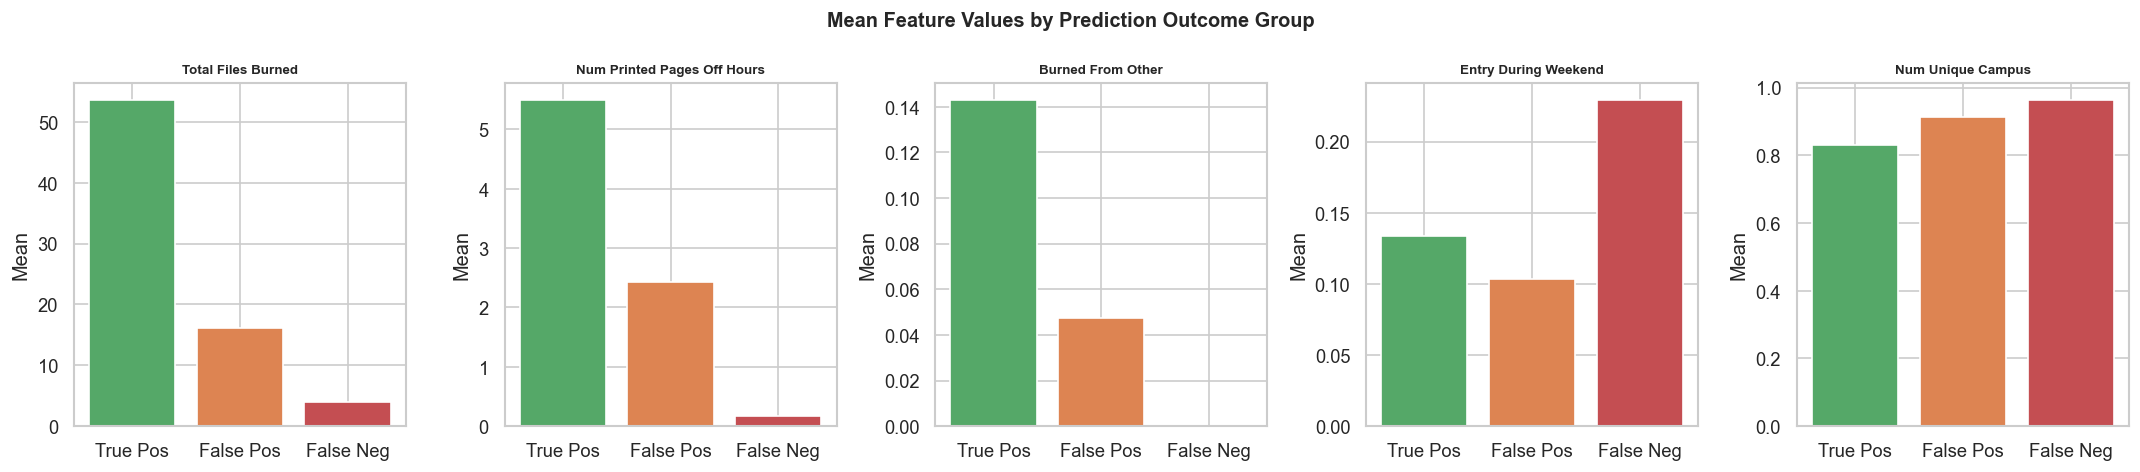

In [16]:
# Visualise key feature means across outcome groups
key_feats = ['total_files_burned', 'num_printed_pages_off_hours', 'burned_from_other',
             'entry_during_weekend', 'num_unique_campus']

fig, axes = plt.subplots(1, len(key_feats), figsize=(18, 4))

for ax, feat in zip(axes, key_feats):
    vals = [tp_rows[feat].mean(), fp_rows[feat].mean(), fn_rows[feat].mean()]
    ax.bar(['True Pos', 'False Pos', 'False Neg'], vals,
           color=['#55A868','#DD8452','#C44E52'], edgecolor='white')
    ax.set_title(feat.replace('_',' ').title(), fontweight='bold', fontsize=8)
    ax.set_ylabel('Mean')

plt.suptitle('Mean Feature Values by Prediction Outcome Group', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Explainability Limitations and Improvements

### Current Approach Limitations
1. **Global importance only** — Gini importance tells us which features matter across all predictions, but does not give exact per-instance contributions. A proper SHAP (SHapley Additive exPlanations) implementation would provide exact local explanations.
2. **Label-encoded categoricals** — the importance scores for encoded categorical columns (e.g. `employee_position`) reflect the encoded integer, not the original label. This can be confusing in explanations.
3. **Proxy features** — features like `num_printed_pages_off_hours` are proxies for behaviour; the model cannot determine intent.

### Suggested Improvements
| Improvement | Benefit |
|---|---|
| Integrate SHAP values | Exact per-prediction feature contributions |
| Add temporal context | Flag if behaviour deviates from the employee's own historical baseline |
| Combine with digital forensic readiness (per Shoderu et al., 2025) | Ensure all anomaly alerts are forensically preserved for investigation |
| Tune the decision threshold | Currently 0.5 — lowering to 0.35 would improve recall at the cost of more FPs |
| Use LIME for complementary local explanations | Provides a linear approximation around each prediction |